# Three-Lens IL System: Distance-First Calibration Workflow

This notebook calibrates the intermediate-lens (IL) system of a TEM from compact
pre-parsed DAC tables so the distance fit can be run immediately.

## Recommended run order

1. Load compact data (cell 2)
2. Read the physics explainer (cell 3)
3. Run distance-first fit and distance analytics (cell 4)
4. Run model evaluation and plots (cell 5)
5. Run d1_img sensitivity scan (cell 6)
6. Run physical diagnostics (cell 7)
7. Optional appendix exploration (later cells)

## Physical setup

Three intermediate lenses (IL1, IL2, IL3) sit between the objective and the
projector. The microscope operates in two modes that share the same IL optics
but differ in object-plane distance $d_1$.

| Mode | Target quantity | Relation |
|------|----------------|----------|
| **Imaging** | system magnification $M_\text{sys}$ | $M_\text{sys} = M_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |
| **Camera length** | $\text{CL}$ [mm] | $\text{CL} = f_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |

Scale factors $s_\text{img}$, $s_\text{cam}$ are fitted so no a-priori knowledge
of $M_\text{obj}$, $M_\text{proj}$, or $f_\text{obj}$ is needed.

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Distance-first compact data tables ====
# These are the same parsed 16-bit-normalized values previously derived from
# the raw hex service-menu tables.

mags_ref = np.array([30000.0, 40000.0, 50000.0, 60000.0, 80000.0, 100000.0,
                     120000.0, 150000.0, 200000.0, 250000.0, 300000.0,
                     400000.0, 500000.0, 600000.0], dtype=float)

cl_ref = np.array([80.0, 100.0, 120.0, 150.0, 200.0, 250.0, 300.0, 400.0,
                   500.0, 600.0, 800.0, 1000.0, 1200.0, 1500.0, 2000.0], dtype=float)

x_img = np.array([
    [0.621612548828125, 0.637542724609375, 0.65020751953125, 0.656494140625,
     0.659820556640625, 0.65625, 0.65557861328125, 0.6538238525390625,
     0.6514434814453125, 0.6510009765625, 0.6485595703125,
     0.64654541015625, 0.6449737548828125, 0.643798828125],
    [0.379364013671875, 0.379364013671875, 0.3929443359375, 0.4151611328125,
     0.443389892578125, 0.489349365234375, 0.489349365234375,
     0.5163726806640625, 0.5839080810546875, 0.5839080810546875,
     0.620208740234375, 0.67596435546875, 0.72369384765625,
     0.7647552490234375],
    [0.6062774658203125, 0.5423583984375, 0.5223236083984375,
     0.4974517822265625, 0.468048095703125, 0.4453887939453125,
     0.4238128662109375, 0.398040771484375, 0.360504150390625,
     0.3326873779296875, 0.2955322265625, 0.242523193359375,
     0.1968994140625, 0.1540679931640625],
], dtype=float)

x_cam = np.array([
    [0.3143310546875, 0.3218536376953125, 0.3208160400390625,
     0.325164794921875, 0.325164794921875, 0.3262176513671875,
     0.3267974853515625, 0.3269500732421875, 0.3263397216796875,
     0.3261871337890625, 0.3243865966796875, 0.3243865966796875,
     0.3234100341796875, 0.3220367431640625, 0.3204345703125],
    [0.6826324462890625, 0.6861724853515625, 0.690277099609375,
     0.6940460205078125, 0.70257568359375, 0.7133636474609375,
     0.7209320068359375, 0.7436981201171875, 0.7699737548828125,
     0.785888671875, 0.822265625, 0.8544921875, 0.8896484375,
     0.93798828125, 0.999755859375],
    [0.57269287109375, 0.5672454833984375, 0.5620269775390625,
     0.55426025390625, 0.5417327880859375, 0.529632568359375,
     0.5180511474609375, 0.4975128173828125, 0.4763641357421875,
     0.45703125, 0.42138671875, 0.390625, 0.358642578125,
     0.311767578125, 0.216796875],
], dtype=float)

print(f"Imaging:  {len(mags_ref)} points,  mag {mags_ref.min():.0f}..{mags_ref.max():.0f}")
print(f"Camera:   {len(cl_ref)} points,  CL {cl_ref.min():.0f}..{cl_ref.max():.0f} mm")
print("Compact data loaded. Proceed directly to distance fit (cell 4).")

Imaging:  14 points,  mag 30000..600000
Camera:   15 points,  CL 80..2000 mm
Compact data loaded. Proceed directly to distance fit (cell 4).


## Analytical Solver (Physics Explainer)

### Magnetic lens optics recap

The optical power (inverse focal length) of a magnetic round lens is

$$\phi \;=\; \frac{e}{8\,m_e\,U^*}\;\int_{-\infty}^{\infty} B_z^2(z)\,dz$$

where $U^* = U(1 + eU/2m_ec^2)$ is the relativistic accelerating potential.
Since $B_z \propto NI$, we get $\phi \propto (NI)^2$ with a proportionality
constant that depends only on geometry (bore, gap, pole pieces):

$$\phi_k \;=\; \underbrace{\alpha_{\mathrm{geom},k} N_k^2 I_{\max}^2}_{\alpha_k}\, x_k^2$$

The fit uses lumped constants $\alpha_k$. If lens geometries are similar,
$\alpha_k$ differences mainly reflect turns-ratio differences.

### Transfer-matrix model

Each thin lens and drift is

$$P(d)=\begin{pmatrix}1 & d\\0 & 1\end{pmatrix},\qquad
L(\phi)=\begin{pmatrix}1 & 0\\-\phi & 1\end{pmatrix}$$

and the IL block is

$$M=P(d_4)L(\phi_3)P(d_3)L(\phi_2)P(d_2)L(\phi_1)P(d_1).$$

Define $A=M_{00}$ and $B=M_{01}$.

For an imaging solution at target IL magnification $m$, we require:

- magnification constraint: $A=m$
- focus constraint: $B=0$

### Why the solver is analytic

Write

$$M = M_{\text{rest}}\,L(\phi_1)\,P(d_1),$$

with $M_{\text{rest}}=P(d_4)L(\phi_3)P(d_3)L(\phi_2)P(d_2)$.
Then top-row terms can be written as

$$A = a - b\phi_1,\qquad B = a d_1 + b(1-d_1\phi_1),$$

where $a,b$ depend only on $(\phi_2,\phi_3)$.
Substitute $\phi_1=(a-m)/b$ from $A=m$ into $B=0$:

$$a d_1 + b - d_1(a-m)=0 \Rightarrow b + d_1 m = 0.$$

So $\phi_1$ cancels out, and we first solve

$$M_{\text{rest}}[0,1] = -d_1 m.$$

This is linear in $\phi_2$ for fixed $\phi_3$, giving a closed form used in code
(`phi2_exact`). Then $\phi_1$ follows from $A=m$ in another closed form
(`phi1_exact`).

### Inverse fit strategy used here

At each measured operating point, we use the measured $x_3$ to set
$\phi_3=\alpha_3 x_3^2$, then compute:

1. $\phi_2^*=\texttt{phi2\_exact}(\phi_3,m,\mathbf d)$
2. $\phi_1^*=\texttt{phi1\_exact}(\phi_2^*,\phi_3,m,\mathbf d)$
3. $x_1^*=\sqrt{\phi_1^*/\alpha_1}$ and $x_2^*=\sqrt{\phi_2^*/\alpha_2}$

Residuals compare $(x_1^*,x_2^*)$ against measured $(x_1,x_2)$.
By construction, each valid point satisfies $A=m$ and $B=0$ exactly.

### Parameters fitted

Nine fit parameters are used:

- distances: $d_1^{img}, d_1^{cam}, d_2, d_4$
- lens constants: $\alpha_1,\alpha_2,\alpha_3$
- mode scales: $s_{img}, s_{cam}$

### Workflow intent

This notebook now runs in a distance-first way:

1. estimate distances and lens constants
2. report distance analytics first
3. evaluate model-vs-data with plots afterward

CAD priors  (d3=62.5 mm):
  d2 = 1.233
  d4 = 0.833
  d1_img = 0.200
  d1_cam = 3.200
Using CAD prior weight for d1_img: 0.00
signs=(+1,+1)  cost=0.003108

Distances (d3=1=62.5 mm):
  d1_img  = 0.2649  (CAD 0.200, +1.6σ)
  d1_cam  = 3.2002  (CAD 3.200, +0.0σ)
  d2      = 1.2340  (CAD 1.233, +0.0σ)
  d4      = 0.8333  (CAD 0.833, -0.0σ)
  alpha   = [11.2090, 17.1272, 6.6595]
  s_img   = 1.1146e-04   →  M_obj·M_proj = 8971.4
  s_cam   = 4.3965e-03   →  f_obj·M_proj = 227.5

Model evaluation:  imaging 14/14, camera 15/15


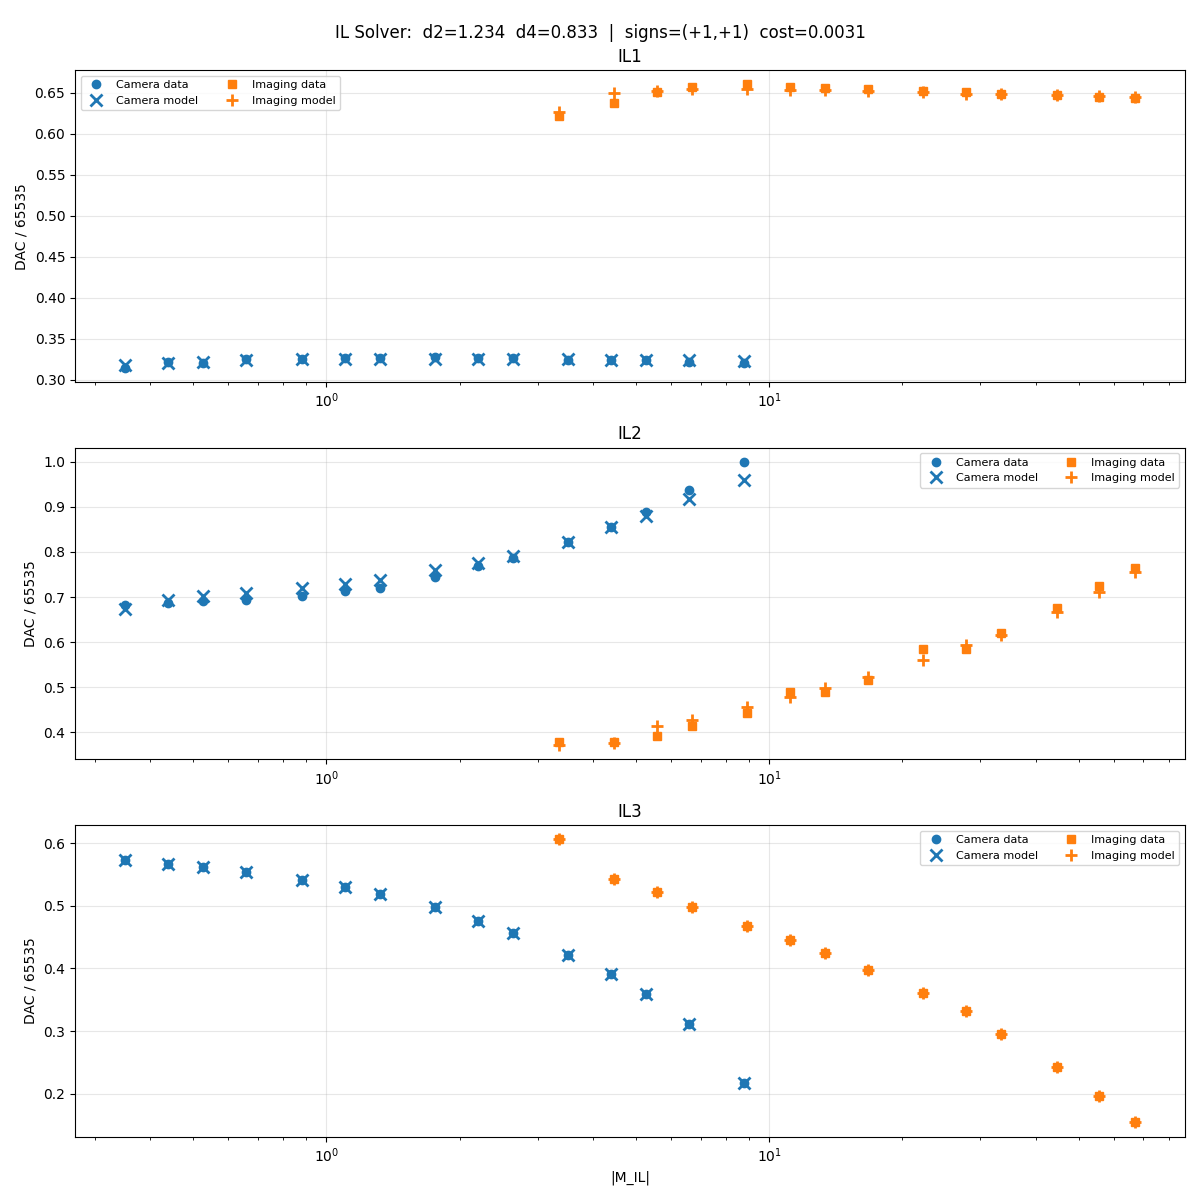


RMSE (model vs data, x3 fixed to data):
  IL1: img=0.00400  cam=0.00146
  IL2: img=0.01217  cam=0.01610
  IL3: img=0.00000  cam=0.00000
  Overall: 0.00845  (29/29 points)


In [ ]:
from scipy.optimize import least_squares, brentq

# ── CAD priors (pixel measurements from measure_microscope_geometry) ──

_px_mm = 200.0 / (624 - 528)
D3_MM = (739 - 709) * _px_mm              # d3 = IL2→IL3 (reference length)
CAD = {
    'd2':     (709 - 672) * _px_mm / D3_MM,
    'd4':     (764 - 739) * _px_mm / D3_MM,
    'd1_img': (672 - 666) * _px_mm / D3_MM,
    'd1_cam': (672 - 576) * _px_mm / D3_MM,
}
CAD_SIGMA = 0.20
W_CAD = 0.35
W_CAD_D1I = 0.0  # Keep d1_img data-driven; CAD estimate is based on only 6 px.

print(f"CAD priors  (d3={D3_MM:.1f} mm):")
for k, v in CAD.items():
    print(f"  {k} = {v:.3f}")
print(f"Using CAD prior weight for d1_img: {W_CAD_D1I:.2f}")

# ── Closed-form B=0 + A=m solutions ─────────────────────────────────

def phi2_exact(phi3, m, d):
    """phi2 from the combined B=0, A=m constraint."""
    d1, d2, d3, d4 = d
    num = d1*m + (d2+d3+d4) - (d2+d3)*d4*phi3
    den = d2*((d3+d4) - d3*d4*phi3)
    return num / den if abs(den) > 1e-30 else np.nan

def phi1_exact(phi2, phi3, m, d):
    """phi1 from A=m with phi2, phi3 known."""
    d1, d2, d3, d4 = d
    A0 = 1.0 - (d3+d4)*phi2 - d4*phi3 + d3*d4*phi2*phi3
    A1 = -(d2+d3+d4) + d2*(d3+d4)*phi2 + (d2+d3)*d4*phi3 - d2*d3*d4*phi2*phi3
    return (m - A0) / A1 if abs(A1) > 1e-30 else np.nan

# ── Inverse fit (distance-first analytics) ───────────────────────────
# 9 parameters: d1_img, d1_cam, d2, d4, log(alpha1), log(alpha2), log(alpha3),
#               log(s_img), log(s_cam)
# si, sc in {+1,-1}: sign of the IL magnification in each mode

def make_residuals(si, sc):
    def fn(p):
        d1i, d1c, d2, d4 = p[:4]
        alpha = np.exp(p[4:7])
        s_i, s_c = np.exp(p[7]), np.exp(p[8])
        d_i, d_c = [d1i, d2, 1.0, d4], [d1c, d2, 1.0, d4]
        res = []
        for x_data, targets, d, s, sign in [
            (x_img, mags_ref, d_i, s_i, si),
            (x_cam, cl_ref,   d_c, s_c, sc),
        ]:
            for j in range(x_data.shape[1]):
                m = sign * s * targets[j]
                p3 = alpha[2] * x_data[2, j]**2
                p2s = phi2_exact(p3, m, d)
                if (not np.isfinite(p2s)) or p2s <= 0:
                    res.extend([1.0, 1.0]); continue
                p1s = phi1_exact(p2s, p3, m, d)
                if (not np.isfinite(p1s)) or p1s <= 0:
                    res.extend([1.0, 1.0]); continue
                res.append(np.sqrt(p1s / alpha[0]) - x_data[0, j])
                res.append(np.sqrt(p2s / alpha[1]) - x_data[1, j])
        # CAD distance priors
        for val, ref in [(d2, CAD['d2']), (d4, CAD['d4'])]:
            res.append(W_CAD * (val - ref) / (CAD_SIGMA * ref))
        res.append(W_CAD_D1I * (d1i - CAD['d1_img']) / (CAD_SIGMA * CAD['d1_img']))
        res.append(W_CAD / 3 * (d1c - CAD['d1_cam']) / (CAD_SIGMA * CAD['d1_cam']))
        return np.array(res)
    return fn

lb = np.array([0.05, 0.10, 0.50, 0.30,
               np.log(0.01), np.log(0.01), np.log(0.01), np.log(1e-7), np.log(1e-7)])
ub = np.array([0.80, 7.0, 2.60, 1.80,
               np.log(1000), np.log(1000), np.log(1000), np.log(1.0), np.log(1.0)])

p0_base = [CAD['d1_img'], CAD['d1_cam'], CAD['d2'], CAD['d4'],
           0, 0, 0, np.log(1/3000), np.log(1/230)]

best, best_cost, best_signs = None, np.inf, (+1, +1)
for si, sc in [(+1,+1), (+1,-1), (-1,+1), (-1,-1)]:
    fn = make_residuals(si, sc)
    for a1, a2, a3 in [(10, 10, 5), (3, 3.5, 2.5), (20, 20, 10), (5, 7, 4)]:
        p0 = list(p0_base)
        p0[4:7] = [np.log(a1), np.log(a2), np.log(a3)]
        try:
            res = least_squares(fn, p0, bounds=(lb, ub), method='trf',
                                max_nfev=20000, diff_step=0.001)
            if res.cost < best_cost:
                best_cost, best, best_signs = res.cost, res, (si, sc)
        except Exception:
            pass

si_best, sc_best = best_signs

# Refine best
fn_best = make_residuals(*best_signs)
res = least_squares(fn_best, best.x, bounds=(lb, ub), method='trf',
                    max_nfev=100000, diff_step=1e-4, ftol=1e-15, xtol=1e-15, gtol=1e-15)
if res.cost <= best_cost:
    best = res

# ── Extract fitted parameters ────────────────────────────────────────

d1i_f, d1c_f, d2_f, d4_f = best.x[:4]
alpha_f = np.exp(best.x[4:7])
s_img_f, s_cam_f = np.exp(best.x[7]), np.exp(best.x[8])
d_img_f = np.array([d1i_f, d2_f, 1.0, d4_f])
d_cam_f = np.array([d1c_f, d2_f, 1.0, d4_f])
m_img = si_best * s_img_f * mags_ref
m_cam = sc_best * s_cam_f * cl_ref

print(f"signs=({si_best:+d},{sc_best:+d})  cost={best.cost:.6f}")
print(f"\nDistance analytics (d3=1={D3_MM:.1f} mm):")
for nm, fit, cad in [('d1_img', d1i_f, CAD['d1_img']), ('d1_cam', d1c_f, CAD['d1_cam']),
                     ('d2', d2_f, CAD['d2']), ('d4', d4_f, CAD['d4'])]:
    print(f"  {nm:7s} = {fit:.4f}  (CAD {cad:.3f}, {(fit-cad)/(CAD_SIGMA*cad):+.1f}sigma)")
print(f"  alpha   = [{alpha_f[0]:.4f}, {alpha_f[1]:.4f}, {alpha_f[2]:.4f}]")
print(f"  s_img   = {s_img_f:.4e}   ->  M_obj*M_proj = {1/s_img_f:.1f}")
print(f"  s_cam   = {s_cam_f:.4e}   ->  f_obj*M_proj = {1/s_cam_f:.1f}")

# ── Model evaluation arrays (used by next plotting cell) ─────────────

def model_at_data(m_arr, x3_data, d, alpha):
    """Evaluate model at calibration points (x3 fixed to data)."""
    out = np.full((3, len(m_arr)), np.nan)
    for j, m in enumerate(m_arr):
        p3 = alpha[2] * x3_data[j]**2
        p2 = phi2_exact(p3, m, d)
        if (not np.isfinite(p2)) or p2 <= 0:
            continue
        p1 = phi1_exact(p2, p3, m, d)
        if (not np.isfinite(p1)) or p1 <= 0:
            continue
        out[0, j] = np.sqrt(p1 / alpha[0])
        out[1, j] = np.sqrt(p2 / alpha[1])
        out[2, j] = x3_data[j]
    return out

pi_f = model_at_data(m_img, x_img[2], d_img_f, alpha_f)
pc_f = model_at_data(m_cam, x_cam[2], d_cam_f, alpha_f)

n_img_ok = int(np.sum(np.isfinite(pi_f[0])))
n_cam_ok = int(np.sum(np.isfinite(pc_f[0])))
print(f"\nPrepared evaluation arrays: imaging {n_img_ok}/{len(m_img)}, camera {n_cam_ok}/{len(m_cam)}")

# ── Optional forward solver utility (for new target settings) ────────

def find_roots(m, d, alpha, r_target, x3_grid):
    """Find all (x1,x2,x3) on A=m, B=0, x1+x2+x3=r_target."""
    d1, d2, d3, d4 = d
    p3 = alpha[2] * x3_grid**2
    den2 = d2 * ((d3 + d4) - d3 * d4 * p3)
    p2 = np.where(np.abs(den2) > 1e-30,
                  (d1 * m + (d2 + d3 + d4) - (d2 + d3) * d4 * p3) / den2, np.nan)
    A0 = 1 - (d3 + d4) * p2 - d4 * p3 + d3 * d4 * p2 * p3
    A1 = -(d2 + d3 + d4) + d2 * (d3 + d4) * p2 + (d2 + d3) * d4 * p3 - d2 * d3 * d4 * p2 * p3
    p1 = np.where(np.abs(A1) > 1e-30, (m - A0) / A1, np.nan)
    ok = np.isfinite(p1) & np.isfinite(p2) & (p1 > 0) & (p2 > 0)
    x1 = np.where(ok, np.sqrt(np.maximum(p1, 0) / alpha[0]), np.nan)
    x2 = np.where(ok, np.sqrt(np.maximum(p2, 0) / alpha[1]), np.nan)
    ok &= np.isfinite(x1) & np.isfinite(x2) & (x1 <= 1.0) & (x2 <= 1.0)
    rot = np.where(ok, x1 + x2 + x3_grid - r_target, np.nan)

    def rot_scalar(x3):
        _p3 = alpha[2] * x3**2
        _p2 = phi2_exact(_p3, m, d)
        if (not np.isfinite(_p2)) or _p2 <= 0:
            return np.nan
        _p1 = phi1_exact(_p2, _p3, m, d)
        if (not np.isfinite(_p1)) or _p1 <= 0:
            return np.nan
        _x1, _x2 = np.sqrt(_p1 / alpha[0]), np.sqrt(_p2 / alpha[1])
        if _x1 > 1.0 or _x2 > 1.0:
            return np.nan
        return _x1 + _x2 + x3 - r_target

    roots = []
    for j in range(len(rot) - 1):
        if np.isfinite(rot[j]) and np.isfinite(rot[j + 1]) and rot[j] * rot[j + 1] < 0:
            try:
                x3s = brentq(rot_scalar, x3_grid[j], x3_grid[j + 1], xtol=1e-12)
            except (ValueError, RuntimeError):
                continue
            p3s = alpha[2] * x3s**2
            p2s = phi2_exact(p3s, m, d)
            p1s = phi1_exact(p2s, p3s, m, d)
            if p1s > 0 and p2s > 0:
                x1s, x2s = np.sqrt(p1s / alpha[0]), np.sqrt(p2s / alpha[1])
                if all(0.005 < v <= 1.0 for v in [x1s, x2s, x3s]):
                    roots.append((x1s, x2s, x3s))
    return roots


def predict_forward(m_arr, d, alpha, r_target, x_ref=None):
    """Forward-predict DAC values with branch continuity (rotation constraint)."""
    out = np.full((3, len(m_arr)), np.nan)
    grid = np.linspace(0.005, 1.0, 3000)
    prev_x3 = None
    for i, m_val in enumerate(m_arr):
        roots = find_roots(m_val, d, alpha, r_target, grid)
        if not roots:
            continue
        if prev_x3 is not None:
            best_rt = min(roots, key=lambda r: abs(r[2] - prev_x3))
        elif x_ref is not None:
            best_rt = min(roots, key=lambda r: abs(r[2] - x_ref[2, i]))
        else:
            best_rt = roots[0]
        out[:, i] = best_rt
        prev_x3 = best_rt[2]
    return out

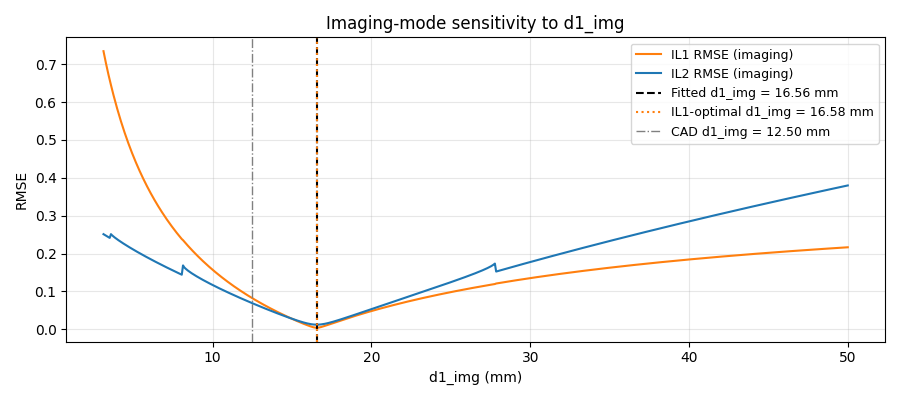

Fitted d1_img      = 16.559 mm
IL1-optimal d1_img = 16.585 mm
CAD d1_img         = 12.500 mm
CAD span is 6 px, so ±1 px is about ±16.7% on d1_img.
Shift from fitted to IL1-optimal d1_img: +0.026 mm
Suggestion: d1_img may not be the sole cause; inspect model form next.


In [34]:
# ── Diagnostic: d1_img sensitivity scan ──────────────────────────────
# Hold all fitted parameters fixed except d1_img and scan how IL1/IL2
# imaging-mode RMSE changes. This identifies whether d1_img is the dominant
# source of IL1 mismatch.

d1_scan = np.linspace(0.05, 0.80, 600)
rmse_il1_img, rmse_il2_img = [], []

for d1_try in d1_scan:
    d_try = np.array([d1_try, d2_f, 1.0, d4_f])
    p = model_at_data(m_img, x_img[2], d_try, alpha_f)

    mi1 = np.isfinite(p[0])
    mi2 = np.isfinite(p[1])
    r1 = np.sqrt(np.mean((p[0, mi1] - x_img[0, mi1])**2)) if np.any(mi1) else np.nan
    r2 = np.sqrt(np.mean((p[1, mi2] - x_img[1, mi2])**2)) if np.any(mi2) else np.nan

    rmse_il1_img.append(r1)
    rmse_il2_img.append(r2)

rmse_il1_img = np.array(rmse_il1_img)
rmse_il2_img = np.array(rmse_il2_img)

best_d1_il1 = d1_scan[np.nanargmin(rmse_il1_img)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d1_scan * D3_MM, rmse_il1_img, color='C1', label='IL1 RMSE (imaging)')
ax.plot(d1_scan * D3_MM, rmse_il2_img, color='C0', label='IL2 RMSE (imaging)')

ax.axvline(d1i_f * D3_MM, color='k', ls='--', lw=1.5,
           label=f'Fitted d1_img = {d1i_f * D3_MM:.2f} mm')
ax.axvline(best_d1_il1 * D3_MM, color='C1', ls=':', lw=1.5,
           label=f'IL1-optimal d1_img = {best_d1_il1 * D3_MM:.2f} mm')
ax.axvline(CAD['d1_img'] * D3_MM, color='gray', ls='-.', lw=1.0,
           label=f'CAD d1_img = {CAD["d1_img"] * D3_MM:.2f} mm')

ax.set_xlabel('d1_img (mm)')
ax.set_ylabel('RMSE')
ax.set_title('Imaging-mode sensitivity to d1_img')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

px_span = (672 - 666)
px_rel_pct = 100.0 / px_span
print(f"Fitted d1_img      = {d1i_f * D3_MM:.3f} mm")
print(f"IL1-optimal d1_img = {best_d1_il1 * D3_MM:.3f} mm")
print(f"CAD d1_img         = {CAD['d1_img'] * D3_MM:.3f} mm")
print(f"CAD span is {px_span} px, so ±1 px is about ±{px_rel_pct:.1f}% on d1_img.")

delta = (best_d1_il1 - d1i_f) * D3_MM
print(f"Shift from fitted to IL1-optimal d1_img: {delta:+.3f} mm")

if np.isfinite(delta) and abs(delta) > 0.5:
    print("Suggestion: re-run fit with weaker or removed d1_img CAD prior.")
else:
    print("Suggestion: d1_img may not be the sole cause; inspect model form next.")

In [40]:
# ── Physical constants (diagnostics only) ─────────────────────────────

M_PROJ = -100.0
U_ACCEL = 200e3
_e, _me, _c = 1.602176634e-19, 9.1093837015e-31, 299792458.0
_mu0 = 1.25663706212e-6
_gamma_rel = 1.0 + _e * U_ACCEL / (_me * _c**2)
_v = _c * np.sqrt(1.0 - 1.0 / _gamma_rel**2)
RC = float(_e * _mu0 / (2.0 * _me * _v))

# ── Derived quantities ────────────────────────────────────────────────

f_obj_mm = 1.0 / (abs(M_PROJ) * s_cam_f)
gamma = np.sqrt(alpha_f / alpha_f[0])

print(f"f_obj = {f_obj_mm:.3f} mm")
print(f"Implied turns ratios  γ = [{gamma[0]:.4f}, {gamma[1]:.4f}, {gamma[2]:.4f}]")
print(f"  If N_1=1000:  N = [{1000*gamma[0]:.0f}, {1000*gamma[1]:.0f}, {1000*gamma[2]:.0f}]")

# ── Real distances (mm) ──────────────────────────────────────────────

print(f"\nDistances (mm):")
print(f"  d1_img = {d1i_f * D3_MM:.1f}   d1_cam = {d1c_f * D3_MM:.1f}")
print(f"  d2     = {d2_f * D3_MM:.1f}   d3     = {D3_MM:.1f}")
print(f"  d4     = {d4_f * D3_MM:.1f}")

# ── Focal lengths at every operating point ───────────────────────────

print(f"\nFocal lengths  f = d3 / (α·x²)  [mm]")
print(f"\n{'Mag':>8s}  {'f1':>8s}  {'f2':>8s}  {'f3':>8s}  {'φ1':>6s}  {'φ2':>6s}  {'φ3':>6s}")
print("-" * 58)
for j in range(len(mags_ref)):
    phi = alpha_f * x_img[:, j]**2
    f = D3_MM / phi
    print(f"{mags_ref[j]:>8.0f}  {f[0]:>8.2f}  {f[1]:>8.2f}  {f[2]:>8.2f}  "
          f"{phi[0]:>6.2f}  {phi[1]:>6.2f}  {phi[2]:>6.2f}")

print(f"\n{'CL (mm)':>8s}  {'f1':>8s}  {'f2':>8s}  {'f3':>8s}  {'φ1':>6s}  {'φ2':>6s}  {'φ3':>6s}")
print("-" * 58)
for j in range(len(cl_ref)):
    phi = alpha_f * x_cam[:, j]**2
    f = D3_MM / phi
    print(f"{cl_ref[j]:>8.0f}  {f[0]:>8.2f}  {f[1]:>8.2f}  {f[2]:>8.2f}  "
          f"{phi[0]:>6.2f}  {phi[1]:>6.2f}  {phi[2]:>6.2f}")

# ── Larmor rotation ──────────────────────────────────────────────────

theta_img = np.degrees(RC * I_MAX * (N_TURNS @ x_img))
theta_cam = np.degrees(RC * I_MAX * (N_TURNS @ x_cam))
print(f"\nLarmor rotation  θ = Rc·I_MAX·Σ(Nk·xk):")
print(f"  Imaging: {np.mean(theta_img):.1f}° ± {np.std(theta_img):.1f}°")
print(f"  Camera:  {np.mean(theta_cam):.1f}° ± {np.std(theta_cam):.1f}°")

# ── Current-sum invariant ────────────────────────────────────────────

r_img_vals = x_img.sum(axis=0)
r_cam_vals = x_cam.sum(axis=0)
print(f"\nΣxk invariant  (lower CV% = more constant):")
print(f"  Imaging: {np.mean(r_img_vals):.4f} ± {np.std(r_img_vals):.4f}  CV={np.std(r_img_vals)/np.mean(r_img_vals)*100:.2f}%")
print(f"  Camera:  {np.mean(r_cam_vals):.4f} ± {np.std(r_cam_vals):.4f}  CV={np.std(r_cam_vals)/np.mean(r_cam_vals)*100:.2f}%")

f_obj = 2.275 mm
Implied turns ratios  γ = [1.0000, 1.2361, 0.7708]
  If N_1=1000:  N = [1000, 1236, 771]

Distances (mm):
  d1_img = 16.6   d1_cam = 200.0
  d2     = 77.1   d3     = 62.5
  d4     = 52.1

Focal lengths  f = d3 / (α·x²)  [mm]

     Mag        f1        f2        f3      φ1      φ2      φ3
----------------------------------------------------------
   30000     14.43     25.36     25.53    4.33    2.46    2.45
   40000     13.72     25.36     31.91    4.56    2.46    1.96
   50000     13.19     23.63     34.40    4.74    2.64    1.82
   60000     12.94     21.17     37.93    4.83    2.95    1.65
   80000     12.81     18.56     42.84    4.88    3.37    1.46
  100000     12.95     15.24     47.31    4.83    4.10    1.32
  120000     12.97     15.24     52.25    4.82    4.10    1.20
  150000     13.04     13.69     59.24    4.79    4.57    1.06
  200000     13.14     10.70     72.21    4.76    5.84    0.87
  250000     13.16     10.70     84.79    4.75    5.84    0.74
  300

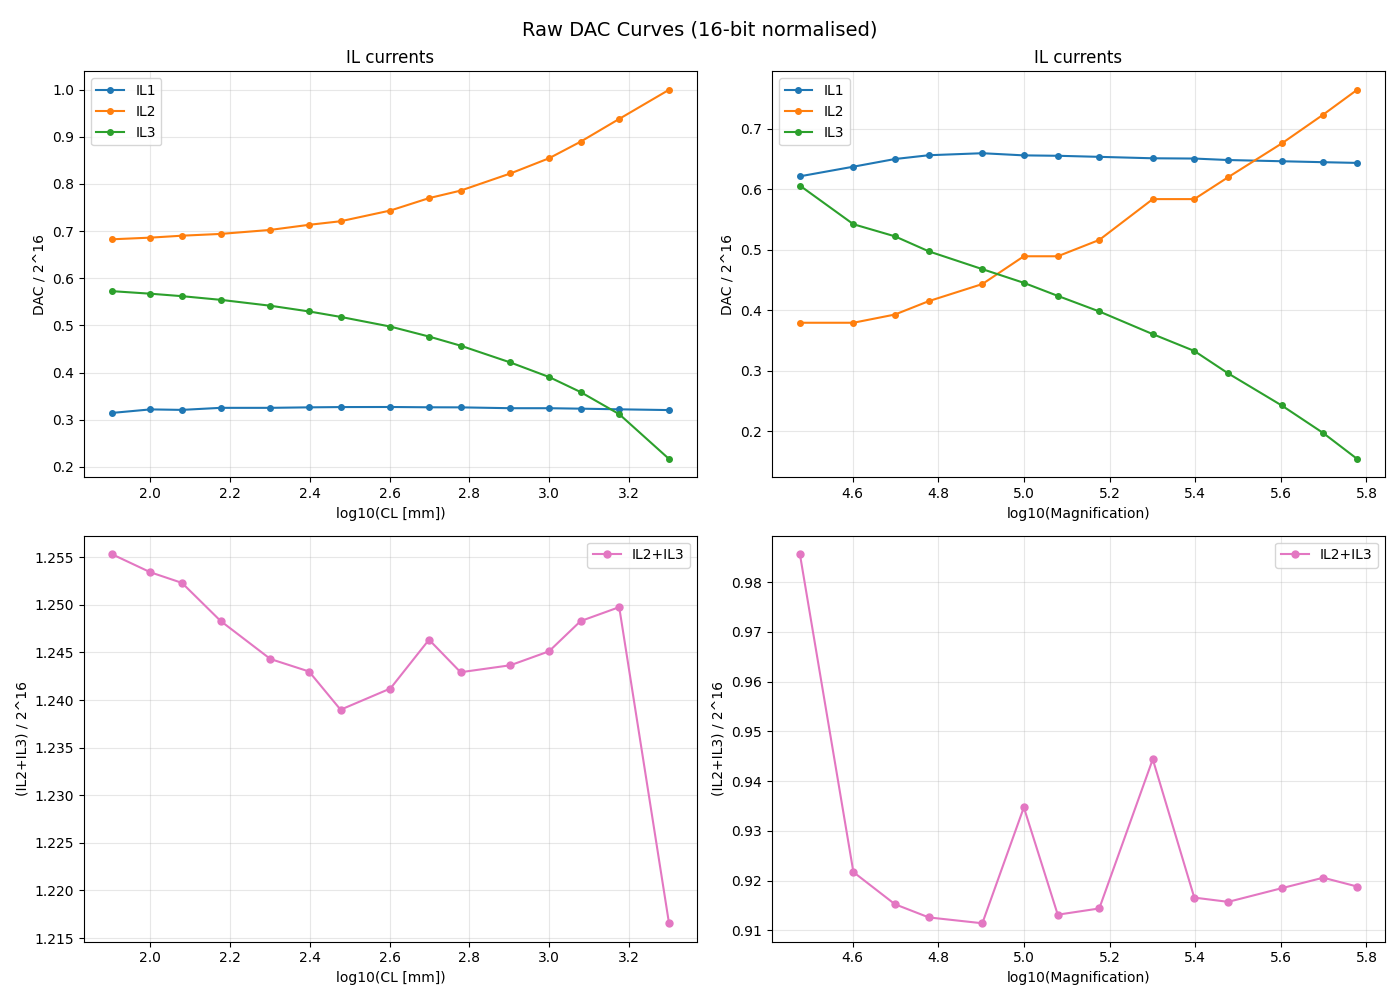

In [35]:
# ── Appendix: raw DAC curve visualisation ────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (primary, x, xlabel) in enumerate([
    (cl_ref, x_cam, "log10(CL [mm])"),
    (mags_ref, x_img, "log10(Magnification)"),
]):
    log_p = np.log10(primary)
    ax = axes[0, col]
    for i, (nm, c) in enumerate(zip(["IL1", "IL2", "IL3"], ["C0", "C1", "C2"])):
        ax.plot(log_p, x[i], "o-", label=nm, color=c, ms=4)
    ax.set_ylabel("DAC / 2^16")
    ax.set_xlabel(xlabel)
    ax.set_title("IL currents")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    ax.plot(log_p, x[1] + x[2], "o-", color="C6", ms=5, label="IL2+IL3")
    ax.set_ylabel("(IL2+IL3) / 2^16")
    ax.set_xlabel(xlabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Raw DAC Curves (16-bit normalised)", fontsize=14)
fig.tight_layout()
plt.show()